In [3]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression

In [19]:
teams = pd.read_csv(r"*ML_Model\teams.csv")
teams = teams[["team", "year", "events", "athletes","age", "medals", "prev_medals"]]
teams

,team,year,events,athletes,age,medals,prev_medals
0,AFG,1964,8,8,22.0,0,0.0
1,AFG,1968,5,5,23.2,0,0.0
2,AFG,1972,8,8,29.0,0,0.0
3,AFG,1980,11,11,23.6,0,0.0
4,AFG,2004,5,5,18.6,0,0.0
...,...,...,...,...,...,...,...
2139,ZIM,2000,19,26,25.0,0,0.0
2140,ZIM,2004,11,14,25.1,3,0.0
2141,ZIM,2008,15,16,26.1,4,3.0
2142,ZIM,2012,8,9,27.3,0,4.0


In [20]:
##LET'S REMOVE ALL NaN VALUES IN TEAMS FIRST
teams = teams.dropna() #DROP ALL ROWS WIT na VALUES
teams[teams.isnull().any(axis=1)] #CHECK EACH ROW INDIVIDUALLY FOR ANY NULL VALUES

,team,year,events,athletes,age,medals,prev_medals


--> DIVIDE TEAMS INTO LOW MEDAL COUNT TEAMS (LMT) AND HIGH MEDAL COUNT TEAMS (HMT)

In [ ]:
##FROMLAST MODEL'S LAST GRAPH, WE SEE THAT THERE IS HUGE ERROR IN PREDICTIONS OF
##TEAMS WITH MEDAL COUNT LESS THAN ABOUT 30. HENCE WE SPLIT DATA INTO DATA WITH MEDAL COUNT
##LESS THAN 30 AND GREATER THAN 30 AND CREATE SEPERATE MODELS

In [25]:
lmt = teams[teams["medals"] <= 40 ].copy()
hmt = teams[teams["medals"] > 40 ].copy()

-->WE CAN TRAIN AN LR MODEL ON HMT THE SAME WAY AS BEFORE, BUT WE SHOULD LOOK INTO A MODEL TO TRAIN ON LMT

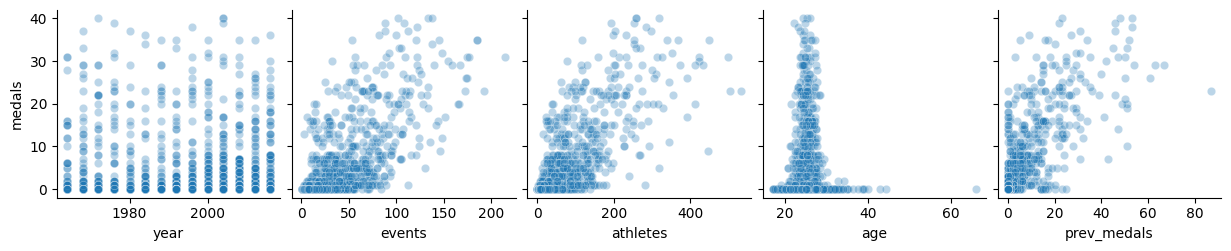

In [23]:
sns.pairplot(data = lmt,x_vars=["year", "events", "athletes","age", "prev_medals"],y_vars="medals" , kind='scatter', plot_kws = {"alpha":0.3})

In [24]:
lmt.drop('team', axis=1).corr()['medals']

year          -0.047905
events         0.746712
athletes       0.785176
age            0.053694
medals         1.000000
prev_medals    0.775620
Name: medals, dtype: float64

-->WE SEE HIGH CORRELATION IN EVENTS, ATHLETES AND PREV_MEDALS

In [47]:
target = ["medals"]
lmt_predictors = ["events", "athletes", "prev_medals"]

-->SPLIT INTO TRAINIG AND TESTING

In [48]:
train_lmt = lmt[lmt["year"] <= 2012 ].copy()
test_lmt = lmt[lmt["year"] > 2012 ].copy()

In [49]:
reg1 = LinearRegression()
reg2 = LinearRegression()

In [50]:
reg1.fit(train_lmt[lmt_predictors], train_lmt["medals"])
reg1.coef_

array([-0.01678648,  0.0535491 ,  0.34429787])

TESTING LMT TRAINED MODEL

In [51]:
predictions = reg1.predict(test_lmt[lmt_predictors])
test_lmt["predictions"] = predictions

CLEAN PREDICTIONS IN REG1

In [52]:
test_lmt.loc[test_lmt["predictions"] < 0, "predictions"] = 0
test_lmt["predictions"] = test_lmt["predictions"].round()
test_lmt

,team,year,events,athletes,age,medals,prev_medals,predictions
7,AFG,2016,3,3,24.7,0,1.0,0.0
25,ALB,2016,6,6,23.7,0,0.0,0.0
38,ALG,2016,48,74,24.0,2,1.0,3.0
49,AND,2016,4,4,26.0,0,0.0,0.0
58,ANG,2016,10,26,27.5,0,0.0,1.0
...,...,...,...,...,...,...,...,...
2091,VIE,2016,24,28,26.9,2,0.0,1.0
2099,VIN,2016,4,4,20.8,0,0.0,0.0
2111,YEM,2016,3,3,19.3,0,0.0,0.0
2132,ZAM,2016,7,7,24.1,0,0.0,0.0


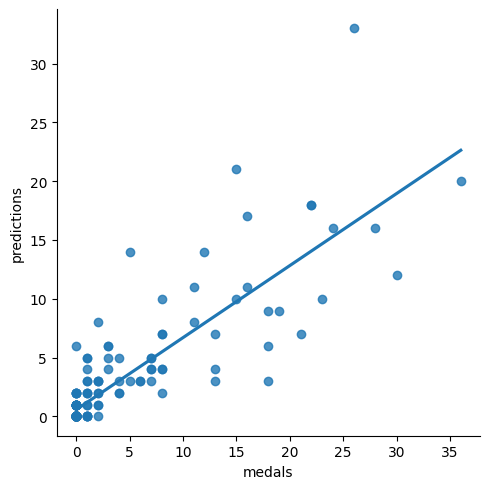

In [53]:
##CHECK HOW CORRECT PREDICTIONS WERE
sns.lmplot(x="medals", y="predictions", data=test_lmt, fit_reg=True, ci=False)

In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mean_abs_err = mean_absolute_error(test_lmt["medals"], test_lmt["predictions"])
mean_sq_err = mean_squared_error(test_lmt["medals"], test_lmt["predictions"])
rmse = np.sqrt(mean_sq_err)

print("Mean abs:",mean_abs_err)
print("Mean sq:",mean_sq_err)
print("Root Mean sq:",rmse)

Mean abs: 1.7204301075268817
Mean sq: 13.580645161290322
Root Mean sq: 3.6851926898454472


--> THERE IS STILL SOME SUBSTANTIAL ERROR. HAVE TO SEE WHAT IT IS ABOUT

--->> TRAIN A MODEL FOR REG2 ;ie; HMT

In [55]:
hmt_predictors = ["athletes", "prev_medals"]

In [67]:
hmt_train = hmt[hmt["year"] <= 2005 ].copy()
test_hmt = hmt[hmt["year"] > 2005 ].copy()

In [74]:
reg2.fit(hmt_train[lmt_predictors], hmt_train[target])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [69]:
reg2.coef_

array([[0.14659994, 0.63367592]])

In [75]:
predictions = reg2.predict(test_hmt[lmt_predictors])
test_hmt["predictions"] = predictions

In [78]:
test_hmt.loc[test_hmt["predictions"] < 0, "predictions"] = 0
test_hmt["predictions"] = test_hmt["predictions"].round()
test_hmt

,team,year,events,athletes,age,medals,prev_medals,predictions
79,ARG,2008,71,145,27.1,51,49.0,36.0
114,AUS,2008,219,570,26.1,149,157.0,152.0
115,AUS,2012,208,514,26.3,114,149.0,133.0
116,AUS,2016,194,518,26.6,82,114.0,128.0
283,BRA,2008,145,338,25.7,78,40.0,50.0
284,BRA,2012,138,306,27.0,59,78.0,63.0
285,BRA,2016,222,583,27.2,50,59.0,101.0
348,CAN,2012,179,354,26.4,55,35.0,23.0
349,CAN,2016,175,405,26.0,69,55.0,61.0
403,CHN,2008,257,730,23.9,184,94.0,155.0


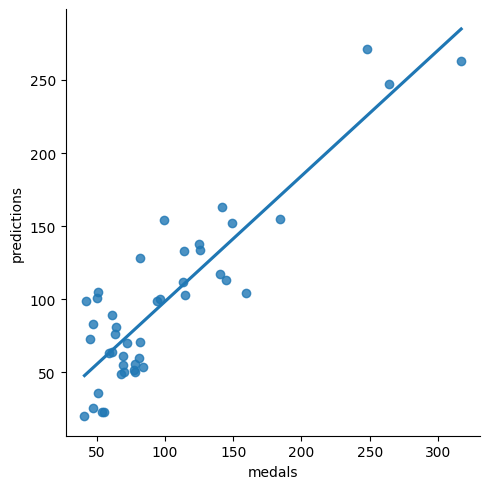

In [79]:
sns.lmplot(x="medals", y="predictions", data=test_hmt, fit_reg=True, ci=False)

In [80]:
mean_abs_err = mean_absolute_error(test_hmt["medals"], test_hmt["predictions"])
mean_sq_err = mean_squared_error(test_hmt["medals"], test_hmt["predictions"])
rmse = np.sqrt(mean_sq_err)

print("Mean abs:",mean_abs_err)
print("Mean sq:",mean_sq_err)
print("Root Mean sq:",rmse)

Mean abs: 23.431818181818183
Mean sq: 797.9318181818181
Root Mean sq: 28.247686952772224


-->>CHECK ERROR RATIOS OF BOTH MODELS NEXT